In [2]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

DINIZ CHAPTER 7 - EXAMPLE 7.1
Number of runs                  : 200
Number of samples               : 600
Unknown-system length           : 8
lambda                          : 0.99
AR(1) pole a                    : 0.6894
Theoretical eigenvalue spread   : 20.000049
Input variance target           : 1.0
Measurement-noise variance      : 1.000000e-04

Algorithm 7.1 - Unnormalized LRLS
epsilon initialization          : 0.1
Measured steady-state MSE       : 1.04181026e-04
Measured misadjustment          : 0.041810
Textbook misadjustment          : 0.041600

Algorithm 7.2 - Normalized LRLS
epsilon initialization          : 0.01
Measured normalized MSE         : 0.00976365
Textbook normalized MSE         : 0.00974000

Differences from textbook:
  Algorithm 7.1                 : +0.000210
  Algorithm 7.2                 : +0.000024


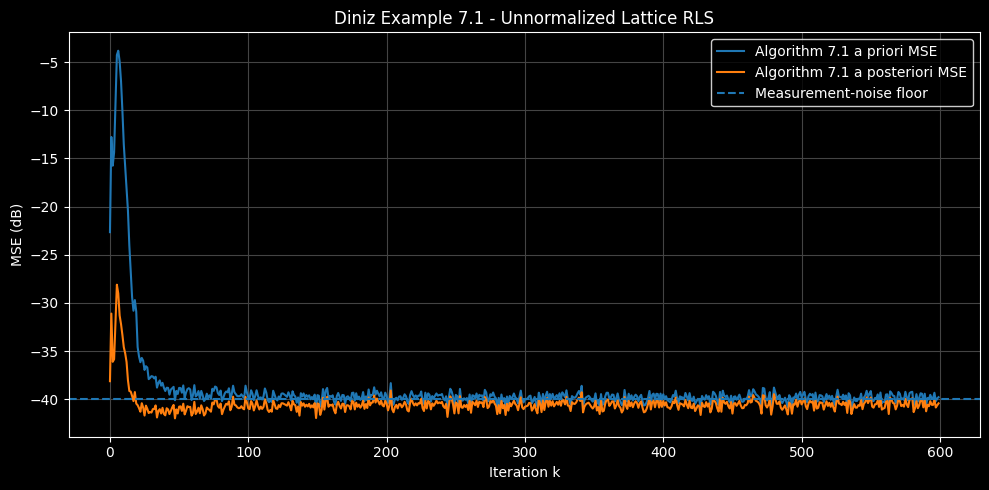

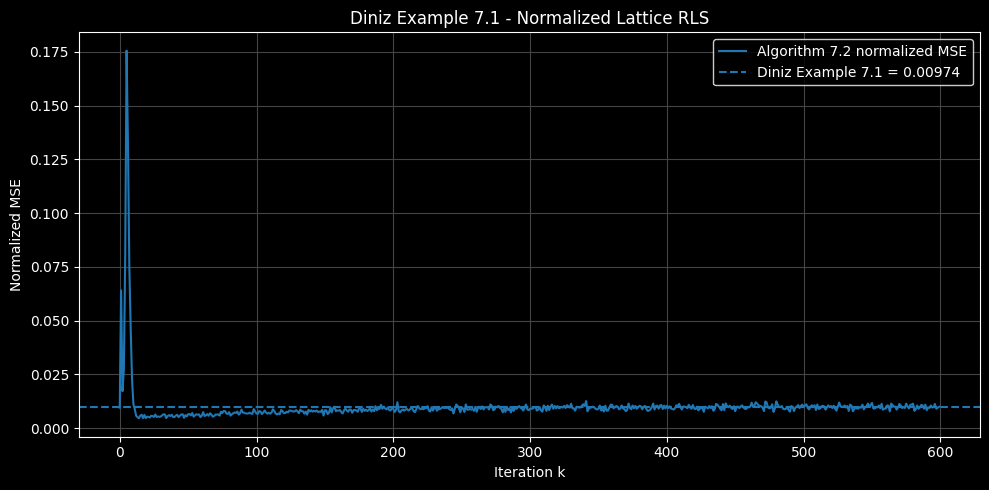

In [4]:
def genColoredInput(n_samples: int, pole: float, rng: np.random.Generator) -> np.ndarray:
  """
  Diniz Example 3.6 colored input:

      H(z) = z / (z - a) = 1 / (1 - a z^-1)

      x(k) = a x(k-1) + v(k)

  with:
      var{x(k)} = 1
      var{v(k)} = 1 - a^2
  """
  sigma_v2 = 1.0 - pole * pole
  v = rng.normal(0.0, np.sqrt(sigma_v2), n_samples)

  x = np.zeros(n_samples, dtype=np.float64)

  for k in range(n_samples):
    x[k] = v[k]
    if k > 0:
      x[k] += pole * x[k - 1]

  return x


def makeDesired(
  x: np.ndarray,
  h: np.ndarray,
  noise_var: float,
  rng: np.random.Generator,
) -> np.ndarray:
  """
  System-identification desired signal:

      d(k) = h^T x_reg(k) + n(k)

  where var{n(k)} = noise_var.
  """
  y_plant = np.convolve(x, h, mode="full")[:len(x)]
  noise = rng.normal(0.0, np.sqrt(noise_var), len(x))

  return y_plant + noise


def inputEigenvalueSpread(pole: float, n_coef: int) -> float:
  """
  Theoretical correlation matrix for var{x}=1:

      R[i,j] = a^|i-j|
  """
  idx = np.arange(n_coef)
  R = pole ** np.abs(idx[:, None] - idx[None, :])

  eig = np.linalg.eigvalsh(R)

  return float(eig[-1] / eig[0])


def runExample71(
  n_runs: int = 200,
  n_samples: int = 600,
  steady_start: int = 300,
  seed: int = 1,
):
  """
  Reproduce the floating-point portion of Diniz Chapter 7 Example 7.1.

  Textbook conditions:
      unknown system taps  = 8
      eigenvalue spread    = 20
      lambda               = 0.99
      measurement var      = 1e-4
      epsilon unnormalized = 0.1
      epsilon normalized   = 0.01
      ensemble runs        = 200

  We use samples 300:600 as the steady-state measurement interval.
  """

  h = np.array(
    [
      0.1,
      0.3,
      0.0,
      -0.2,
      -0.4,
      -0.7,
      -0.4,
      -0.2,
    ],
    dtype=np.float64,
  )

  n_coef = len(h)
  filter_order = n_coef - 1

  pole = 0.6894
  lam = 0.99
  noise_var = 1e-4

  epsilon_lrls = 0.1
  epsilon_norm = 0.01

  rng = np.random.default_rng(seed)

  mse_apriori = np.zeros(n_samples, dtype=np.float64)
  mse_aposteriori = np.zeros(n_samples, dtype=np.float64)
  normalized_mse = np.zeros(n_samples, dtype=np.float64)

  for _ in range(n_runs):
    x = genColoredInput(
      n_samples=n_samples,
      pole=pole,
      rng=rng,
    )

    d = makeDesired(
      x=x,
      h=h,
      noise_var=noise_var,
      rng=rng,
    )

    # ----------------------------------------------------------
    # Algorithm 7.1
    # ----------------------------------------------------------

    lrls = adspfilter.LatticeRLS(
      filter_order=filter_order,
      lam=lam,
      epsilon=epsilon_lrls,
    )

    for k in range(n_samples):
      result = lrls.step(x[k], d[k])

      # Algorithm 7.1 directly generates the a posteriori joint-process error:
      #
      #   epsilon(k, N+1)
      #
      eps_post = float(result["e"])

      # From:
      #
      #   epsilon(k, i) = gamma(k, i) e(k, i)
      #
      # recover the a priori error required for the textbook misadjustment:
      gamma_out = float(result["gamma"][-1])
      e_prior = eps_post / max(gamma_out, lrls.eps)

      mse_apriori[k] += e_prior * e_prior
      mse_aposteriori[k] += eps_post * eps_post

    # ----------------------------------------------------------
    # Algorithm 7.2
    # ----------------------------------------------------------

    nlrls = adspfilter.NormalizedLatticeRLS(
      filter_order=filter_order,
      lam=lam,
      epsilon=epsilon_norm,
    )

    for k in range(n_samples):
      result = nlrls.step(
        x[k],
        d[k],
      )

      e_bar = float(result["e_bar"])
      normalized_mse[k] += e_bar * e_bar

  mse_apriori /= n_runs
  mse_aposteriori /= n_runs
  normalized_mse /= n_runs

  steady = slice(steady_start, n_samples)

  mse_ss = float(np.mean(mse_apriori[steady]))

  # Since the optimum MMSE is the independent measurement-noise variance:
  #
  #   M = (MSE - xi_min) / xi_min
  #
  # with xi_min = sigma_n^2.
  misadjustment = (mse_ss - noise_var) / noise_var

  normalized_mse_ss = float(np.mean(normalized_mse[steady]))

  spread = inputEigenvalueSpread(
    pole=pole,
    n_coef=n_coef,
  )

  print("=" * 72)
  print("DINIZ CHAPTER 7 - EXAMPLE 7.1")
  print("=" * 72)

  print(f"Number of runs                  : {n_runs}")
  print(f"Number of samples               : {n_samples}")
  print(f"Unknown-system length           : {n_coef}")
  print(f"lambda                          : {lam}")
  print(f"AR(1) pole a                    : {pole}")
  print(f"Theoretical eigenvalue spread   : {spread:.6f}")
  print(f"Input variance target           : 1.0")
  print(f"Measurement-noise variance      : {noise_var:.6e}")

  print()
  print("Algorithm 7.1 - Unnormalized LRLS")
  print(f"epsilon initialization          : {epsilon_lrls}")
  print(f"Measured steady-state MSE       : {mse_ss:.8e}")
  print(f"Measured misadjustment          : {misadjustment:.6f}")
  print(f"Textbook misadjustment          : {0.0416:.6f}")

  print()
  print("Algorithm 7.2 - Normalized LRLS")
  print(f"epsilon initialization          : {epsilon_norm}")
  print(f"Measured normalized MSE         : {normalized_mse_ss:.8f}")
  print(f"Textbook normalized MSE         : {0.00974:.8f}")

  print()
  print("Differences from textbook:")
  print(f"  Algorithm 7.1                 : {misadjustment - 0.0416:+.6f}")
  print(f"  Algorithm 7.2                 : {normalized_mse_ss - 0.00974:+.6f}")
  print("=" * 72)

  # Broad statistical tolerances: results are Monte-Carlo estimates.
  assert abs(spread - 20.0) < 0.01
  assert abs(misadjustment - 0.0416) < 0.02
  assert abs(normalized_mse_ss - 0.00974) < 0.002

  return {
    "mse_apriori": mse_apriori,
    "mse_aposteriori": mse_aposteriori,
    "normalized_mse": normalized_mse,
    "misadjustment": misadjustment,
    "normalized_mse_ss": normalized_mse_ss,
    "spread": spread,
  }


def plotExample71(result):
  mse_apriori = result["mse_apriori"]
  mse_aposteriori = result["mse_aposteriori"]
  normalized_mse = result["normalized_mse"]

  k = np.arange(len(mse_apriori))

  plt.figure(figsize=(10, 5))

  plt.plot(
    k,
    10.0 * np.log10(np.maximum(mse_apriori, 1e-16)),
    label="Algorithm 7.1 a priori MSE",
  )

  plt.plot(
    k,
    10.0 * np.log10(np.maximum(mse_aposteriori, 1e-16)),
    label="Algorithm 7.1 a posteriori MSE",
  )

  plt.axhline(
    10.0 * np.log10(1e-4),
    linestyle="--",
    label="Measurement-noise floor",
  )

  plt.xlabel("Iteration k")
  plt.ylabel("MSE (dB)")
  plt.title("Diniz Example 7.1 - Unnormalized Lattice RLS")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()

  plt.figure(figsize=(10, 5))

  plt.plot(
    k,
    normalized_mse,
    label="Algorithm 7.2 normalized MSE",
  )

  plt.axhline(
    0.00974,
    linestyle="--",
    label="Diniz Example 7.1 = 0.00974",
  )

  plt.xlabel("Iteration k")
  plt.ylabel("Normalized MSE")
  plt.title("Diniz Example 7.1 - Normalized Lattice RLS")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()

  plt.show()


if __name__ == "__main__":
  result = runExample71()
  plotExample71(result)